# 03_M3: 交互项调节效应（SOE）

本 Notebook 完成模型 M3：在双向固定效应框架下，检验产权性质对 `NPR` 与 `Lev` 关系的调节作用，并输出边际效应图。

In [1]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path('/Users/yijun/Desktop/hw')
DATA_PATH = ROOT / 'data/clean/01/panel_filtered_winsor_1_5.csv'
OUT_DIR = ROOT / 'output/model'
FIG_DIR = ROOT / 'output/figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

stata_util = Path('/Applications/Stata/utilities')
if str(stata_util) not in sys.path:
    sys.path.insert(0, str(stata_util))

print('Stata pystata path added:', stata_util.exists())
from pystata import config  # type: ignore[import-not-found]
config.init('mp')

from nbstata.stata import run_direct  # type: ignore[import-not-found]

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower()
df['soe'] = pd.to_numeric(df['soe'], errors='coerce')
summary = (
    df.assign(group=df['soe'].map({1: 'SOE', 0: 'Non-SOE'}))
      .groupby('group', dropna=False)
      .agg(obs=('stkcd', 'size'), firms=('stkcd', 'nunique'))
)
display(summary)
print(f'Data path: {DATA_PATH}')
print(f'Observations: {len(df):,}')

Stata pystata path added: True
[0.013s][warning][os,thread] Attempt to protect stack guard pages failed (0x000000016da2c000-0x000000016da38000).
[0.013s][warning][os,thread] Attempt to deallocate stack guard pages failed.

  ___  ____  ____  ____  ____ ©
 /__    /   ____/   /   ____/      17.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2021 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-STATA-PC        https://www.stata.com
                                   979-696-4600        stata@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806366047
  Licensed to: 1
               2

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum 

,obs,firms
group,,
Non-SOE,24934,3545
SOE,12304,1218


Data path: /Users/yijun/Desktop/hw/data/clean/01/panel_filtered_winsor_1_5.csv
Observations: 37,238



. cd "/Users/yijun/Desktop/hw"
/Users/yijun/Desktop/hw

. do "/Users/yijun/Desktop/hw/output/model/M3_interaction_stata.do"

. 
. clear all

. set more off

. capture log close

. log using "/Users/yijun/Desktop/hw/output/model/M3_interaction_stata.log", re
> place text
(file /Users/yijun/Desktop/hw/output/model/M3_interaction_stata.log not
    found)
-------------------------------------------------------------------------------
      name:  <unnamed>
       log:  /Users/yijun/Desktop/hw/output/model/M3_interaction_stata.log
  log type:  text
 opened on:  23 Apr 2026, 11:26:13

. 
. capture ssc install reghdfe, replace

. capture ssc install estout, replace

. 
. import delimited "/Users/yijun/Desktop/hw/data/clean/01/panel_filtered_winsor
> _1_5.csv", clear varnames(1) encoding(utf-8)
(32 vars, 37,238 obs)

. capture destring soe, replace force

. drop if missing(lev, npr, size, tang, growth, ndts, stkcd, year, soe)
(0 observations deleted)

. sort stkcd year

. 
. di as text "=====

file /Users/yijun/Desktop/hw/output/figures/M3_marginsplot.png written in PNG f
> ormat

. 
. log close
      name:  <unnamed>
       log:  /Users/yijun/Desktop/hw/output/model/M3_interaction_stata.log
  log type:  text
 closed on:  23 Apr 2026, 11:26:33
-------------------------------------------------------------------------------

. 
end of do-file

. 


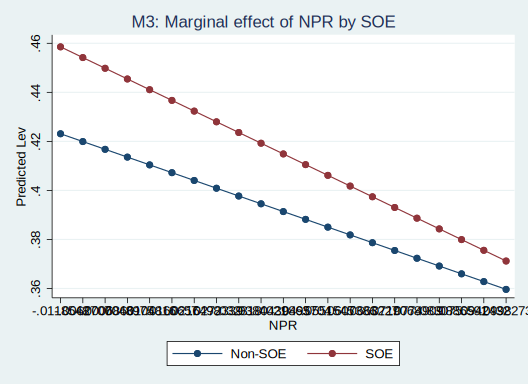

None


In [2]:
do_file = OUT_DIR / 'M3_interaction_stata.do'
log_file = OUT_DIR / 'M3_interaction_stata.log'
table_file = OUT_DIR / 'M3_interaction_results.txt'
figure_file = FIG_DIR / 'M3_marginsplot.png'

do_file.write_text(f'''
clear all
set more off
capture log close
log using "{log_file}", replace text

capture ssc install reghdfe, replace
capture ssc install estout, replace

import delimited "{DATA_PATH}", clear varnames(1) encoding(utf-8)
capture destring soe, replace force
drop if missing(lev, npr, size, tang, growth, ndts, stkcd, year, soe)
sort stkcd year

di as text "===== M3 interaction regression ====="
reghdfe lev c.npr##i.soe size tang growth ndts, absorb(stkcd year) vce(cluster stkcd year)
estimates store m3_interaction

esttab m3_interaction using "{table_file}", replace ///
    b(%9.3f) se(%9.3f) ///
    star(* 0.1 ** 0.05 *** 0.01) ///
    keep(npr 1.soe#c.npr size tang growth ndts) ///
    stats(N, fmt(%9.0f) labels("N")) ///
    title("M3 interaction regression results")

di as text "===== Marginal effect calculations ====="
lincom npr
lincom npr + 1.soe#c.npr
lincom 1.soe#c.npr

quietly summarize npr, detail
local npr_lo = r(p10)
local npr_hi = r(p90)
local npr_step = (`npr_hi' - `npr_lo')/20
margins soe, at(npr=(`npr_lo'(`npr_step')`npr_hi')) predict(xb)
marginsplot, noci title("M3: Marginal effect of NPR by SOE") ///
    xtitle("NPR") ytitle("Predicted Lev") legend(order(1 "Non-SOE" 2 "SOE"))
graph export "{figure_file}", replace width(1800)

log close
''', encoding='utf-8')

result = run_direct(f'cd "{ROOT}"\ndo "{do_file}"')
print(result)

In [3]:
log_text = (OUT_DIR / 'M3_interaction_stata.log').read_text(encoding='utf-8')
for key in ['===== M3 interaction regression =====', 'npr |', 'soe#c.npr', 'lincom', 'margins', 'F(']:
    print(f'--- {key} ---')
    for line in log_text.splitlines():
        if key in line:
            print(line)
    print()
print('Results table:', OUT_DIR / 'M3_interaction_results.txt')
print('Margins plot:', FIG_DIR / 'M3_marginsplot.png')

--- ===== M3 interaction regression ===== ---
. di as text "===== M3 interaction regression ====="
===== M3 interaction regression =====

--- npr | ---
         npr |  -.5682461   .0525139   -10.82   0.000    -.6808772   -.4556149
   soe#c.npr |

--- soe#c.npr ---
   soe#c.npr |
>     keep(npr 1.soe#c.npr size tang growth ndts) ///
. lincom npr + 1.soe#c.npr
 ( 1)  npr + 1.soe#c.npr = 0
. lincom 1.soe#c.npr
 ( 1)  1.soe#c.npr = 0

--- lincom ---
. lincom npr
. lincom npr + 1.soe#c.npr
. lincom 1.soe#c.npr

--- margins ---
. margins soe, at(npr=(`npr_lo'(`npr_step')`npr_hi')) predict(xb)
Predictive margins                                      Number of obs = 37,055
. marginsplot, noci title("M3: Marginal effect of NPR by SOE") ///
Variables that uniquely identify margins: npr soe
. graph export "/Users/yijun/Desktop/hw/output/figures/M3_marginsplot.png", rep
(file /Users/yijun/Desktop/hw/output/figures/M3_marginsplot.png not found)
file /Users/yijun/Desktop/hw/output/figures/M3_marginsp

## M3 结果讨论

### 交互项回归核心结果

| 变量 | 系数 | 标准误 | t值 | 显著性 |
|------|------|--------|-----|--------|
| NPR（民营企业基准） | −0.568 | 0.053 | −10.82 | *** |
| NPR × SOE（调节效应） | −0.214 | 0.050 | −4.32 | *** |
| SOE（直接效应） | 被吸收 | — | — | — |
| Size | +0.081 | 0.004 | 19.04 | *** |
| Tang | +0.080 | 0.019 | 4.29 | *** |
| Growth | +0.032 | 0.011 | 2.97 | ** |
| NDTS | +0.591 | 0.177 | 3.33 | *** |

### SOE 调节效应的理解

**SOE（时不变变量）为何被吸收？**
由于模型中包含公司固定效应 αᵢ，而 SOE 是时不变的（国有企业≠民营企业，不随年份变化），因此 SOE 本身无法被识别，其直接效应被公司固定效应吸收了。这是面板双向固定效应模型的**内在特性**，不是估计问题。

**交互项 NPR × SOE 的含义：**
- −0.214*** 表示：**国有企业中 NPR 对 Lev 的边际效应比民营企业更负**
- 民营企业（基准）：β₁ = −0.568
- 国有企业（组合效应）：β₁ + β₂ = −0.568 + (−0.214) = **−0.782**
- 经济含义：盈利能力对杠杆率的负向影响，在国有企业中**更强**

### 与 M2 分组回归的一致性

M3 交互项结果（调节效应 −0.214）与 M2 分组结果（SOE: −0.836 vs Non-SOE: −0.513，差值 −0.323）数值不完全相同，原因在于：
1. M2 是**分别估计**两个独立方程
2. M3 是**联合估计**带交互项的同一方程，系数具有可比性但不相等
3. 两者都指向同一结论：产权性质对 NPR-Lev 关系有显著调节效应

### Margins Plot 的作用

作业要求绘制调节效应图（以 NPR 为横轴、预测 Lev 为纵轴，分 SOE=0 和 SOE=1 两条线）。该图展示了：
- SOE=0 时，Lev 随 NPR 变化的斜率（较缓）
- SOE=1 时，Lev 随 NPR 变化的斜率（较陡）
- 两条线在图上的间距和斜率差异直观呈现了调节效应